<div style=" background-color: #3D839B;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Analysez les ventes d'une librairie 
</h2>
</div>

<div style="background-color:#3D839B ;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Step 1 - Import and Loading Excel files</h2>
</div>

<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.1 - Import of bookstores</h3>
</div>

In [63]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import scipy.stats as st
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.formula.api import ols
warnings.filterwarnings('ignore')

In [64]:
from scipy.stats import pearsonr, spearmanr
from scipy.stats import f_oneway

In [65]:
from scipy.stats import chi2_contingency


<div style="border: 1px solid #224F59;" >
<h3 style="margin: auto; padding: 20px; color: #224F59; ">1.2 - Loading Excel files</h3>
</div>

In [66]:
 products = pd.read_csv("products.csv",sep=';')

In [67]:
Transactions = pd.read_csv(
    "Transactions.csv",
    sep=';',
    dtype={
        "id_prod": str,
        "session_id": str,
        "client_id": str
    },
    parse_dates=["date"]
)

In [68]:
customers= pd.read_csv("customers.csv",sep=';')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier  products</h3>
</div>

In [69]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3286 non-null   object 
 1   price    3286 non-null   float64
 2   categ    3286 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.1+ KB


In [70]:
products.head()

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [71]:
#Ecommerce["Transaction_Date"] = pd.to_datetime(Ecommerce["Transaction_Date"], format="%Y-%m-%d")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier Transactions </h3>
</div>

In [72]:
Transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 21.0+ MB


In [73]:
Transactions.head()


,id_prod,date,session_id,client_id
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier customers </h3>
</div>

In [74]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8621 entries, 0 to 8620
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8621 non-null   object
 1   sex        8621 non-null   object
 2   birth      8621 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [75]:
customers.head()

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [76]:
print(customers[customers["client_id"] == "c_4410"])


  client_id sex  birth
0    c_4410   f   1967


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Fusion des fichiers
 </h3>
</div>

In [77]:
df_tra_pro = Transactions.merge(products, on='id_prod', how='left', indicator=True)

In [78]:
df_tra_pro = df_tra_pro.drop(columns=['_merge'], errors='ignore')


In [79]:
df = df_tra_pro.merge(customers, on='client_id', how='left', indicator=True)

In [80]:
df['_merge'].unique().tolist()

['both']

In [81]:
print("Données fusionnées:")
display(df.head())

Données fusionnées:


,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Création des colonnes supplémentaire
 </h3>
</div>

In [82]:
# Chiffre d'affaires (prix par transaction)
df['ca'] = df['price'] 

# Colonnes de date
df['jour'] = df['date'].dt.date


In [83]:
df = df.dropna(subset=['date'])

df['semaine'] = df['date'].dt.to_period('W').dt.start_time
df['mois'] = df['date'].dt.to_period('M').dt.start_time

In [84]:
print("Données fusionnées:")
display(df.head())

Données fusionnées:


,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge,ca,jour,semaine,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both,11.99,2021-03-01,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both,19.37,2021-03-01,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both,4.50,2021-03-01,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both,6.55,2021-03-01,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both,16.49,2021-03-01,2021-03-01,2021-03-01


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   price       687534 non-null  float64       
 5   categ       687534 non-null  int64         
 6   sex         687534 non-null  object        
 7   birth       687534 non-null  int64         
 8   _merge      687534 non-null  category      
 9   ca          687534 non-null  float64       
 10  jour        687534 non-null  object        
 11  semaine     687534 non-null  datetime64[ns]
 12  mois        687534 non-null  datetime64[ns]
dtypes: category(1), datetime64[ns](3), float64(2), int64(2), object(5)
memory usage: 63.6+ MB


In [86]:
df['categ'] = df['categ'].astype(int)      
df['birth'] = df['birth'].astype(int)     
df['sex'] = df['sex'].astype('category')  
df['categ'] = df['categ'].astype('category')  


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687534 entries, 0 to 687533
Data columns (total 13 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     687534 non-null  object        
 1   date        687534 non-null  datetime64[ns]
 2   session_id  687534 non-null  object        
 3   client_id   687534 non-null  object        
 4   price       687534 non-null  float64       
 5   categ       687534 non-null  category      
 6   sex         687534 non-null  category      
 7   birth       687534 non-null  int64         
 8   _merge      687534 non-null  category      
 9   ca          687534 non-null  float64       
 10  jour        687534 non-null  object        
 11  semaine     687534 non-null  datetime64[ns]
 12  mois        687534 non-null  datetime64[ns]
dtypes: category(3), datetime64[ns](3), float64(2), int64(1), object(4)
memory usage: 54.4+ MB


In [88]:
df.head()

,id_prod,date,session_id,client_id,price,categ,sex,birth,_merge,ca,jour,semaine,mois
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,both,11.99,2021-03-01,2021-03-01,2021-03-01
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,both,19.37,2021-03-01,2021-03-01,2021-03-01
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,both,4.50,2021-03-01,2021-03-01,2021-03-01
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,both,6.55,2021-03-01,2021-03-01,2021-03-01
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,both,16.49,2021-03-01,2021-03-01,2021-03-01


In [89]:
df[['date','birth']].dtypes


date     datetime64[ns]
birth             int64
dtype: object

In [90]:
df['year'] = df['date'].dt.year
df['age'] = df['year'] - df['birth']


In [91]:
df['age'].describe()


count    687534.000000
mean         43.844898
std          13.623882
min          17.000000
25%          35.000000
50%          42.000000
75%          51.000000
max          94.000000
Name: age, dtype: float64

In [92]:
spend_per_client = df.groupby('client_id')['ca'].sum().sort_values(ascending=False)
b2b_clients = spend_per_client.head(4).index.tolist()
b2b_clients


['c_1609', 'c_4958', 'c_6714', 'c_3454']

In [93]:
df_stat = df[~df['client_id'].isin(b2b_clients)].copy()


In [94]:
client_metrics = df_stat.groupby('client_id').agg(
    age=('age','first'),
    total_spend=('ca','sum'),
    frequency=('session_id','nunique')
).reset_index()

client_metrics['panier_moyen'] = client_metrics['total_spend'] / client_metrics['frequency']
client_metrics.head()


,client_id,age,total_spend,frequency,panier_moyen
0,c_1,66,629.02,34,18.500588
1,c_10,65,1353.60,34,39.811765
2,c_100,29,254.85,5,50.970000
3,c_1000,55,2291.88,94,24.381702
4,c_1001,39,1823.85,47,38.805319


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">(Sex ↔ Catégorie) Khi2 (Chi-square)</h2>
</div>

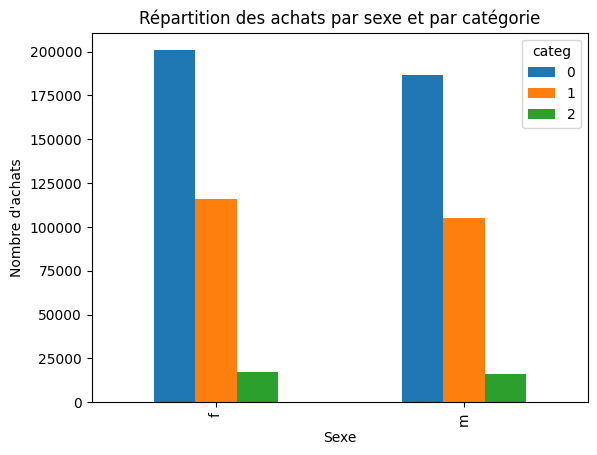

In [95]:
ct = pd.crosstab(df_stat['sex'], df_stat['categ'])   # counts
ct.plot(kind='bar')
plt.title("Répartition des achats par sexe et par catégorie")
plt.xlabel("Sexe")
plt.ylabel("Nombre d'achats")
plt.show()

In [96]:

chi2, p, dof, expected = chi2_contingency(ct)
chi2, p, dof


(22.66856665178056, 1.1955928116587024e-05, 2)

In [97]:

chi2, p, dof, expected = chi2_contingency(ct)
n = ct.to_numpy().sum()
r, k = ct.shape
cramers_v = np.sqrt(chi2 / (n * (min(r-1, k-1))))
cramers_v


0.005948029928802536

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">(Âge ↔ Montant total) Pearson Spearman</h2>
</div>

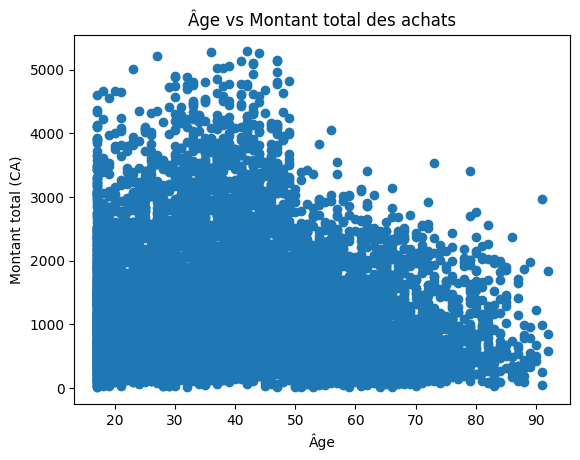

In [98]:
plt.scatter(client_metrics['age'], client_metrics['total_spend'])
plt.title("Âge vs Montant total des achats")
plt.xlabel("Âge")
plt.ylabel("Montant total (CA)")
plt.show()


In [99]:


pearson_r, pearson_p = pearsonr(client_metrics['age'], client_metrics['total_spend'])
spearman_r, spearman_p = spearmanr(client_metrics['age'], client_metrics['total_spend'])

pearson_r, pearson_p, spearman_r, spearman_p


(-0.18769866037331878,
 5.33950203683415e-69,
 -0.18471542941750804,
 7.624128461015447e-67)

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">(Âge ↔ Fréquence)  Spearman/Pearson (CA)</h2>
</div>

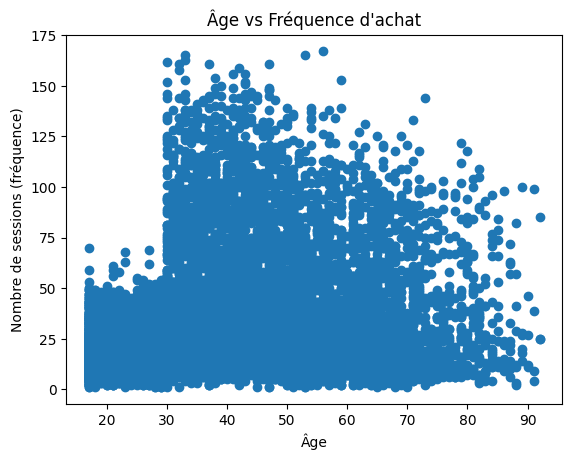

In [100]:
plt.scatter(client_metrics['age'], client_metrics['frequency'])
plt.title("Âge vs Fréquence d'achat")
plt.xlabel("Âge")
plt.ylabel("Nombre de sessions (fréquence)")
plt.show()


In [101]:
pearsonr(client_metrics['age'], client_metrics['frequency']), spearmanr(client_metrics['age'], client_metrics['frequency'])


(PearsonRResult(statistic=0.16437446401542116, pvalue=3.9966507322165026e-53),
 SignificanceResult(statistic=0.21180048350425132, pvalue=9.056486138593036e-88))

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">(Âge ↔ Panier moyen) Spearman/Pearson</h2>
</div>

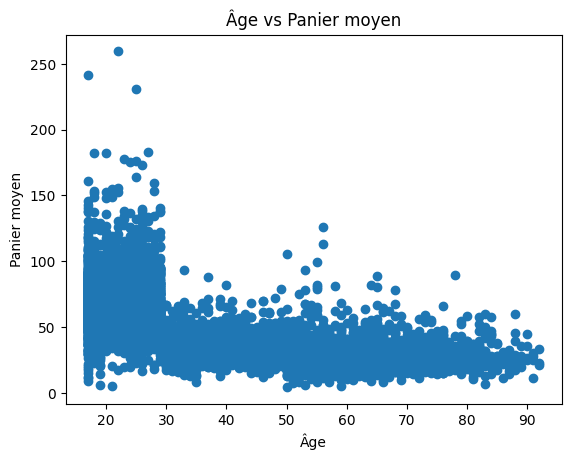

In [102]:
plt.scatter(client_metrics['age'], client_metrics['panier_moyen'])
plt.title("Âge vs Panier moyen")
plt.xlabel("Âge")
plt.ylabel("Panier moyen")
plt.show()


In [103]:
pearsonr(client_metrics['age'], client_metrics['panier_moyen']), spearmanr(client_metrics['age'], client_metrics['panier_moyen'])


(PearsonRResult(statistic=-0.6164879420481755, pvalue=0.0),
 SignificanceResult(statistic=-0.700546520416792, pvalue=0.0))

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">(Âge ↔ Catégorie) “Quantitative vs Categorical”</h2>
</div>

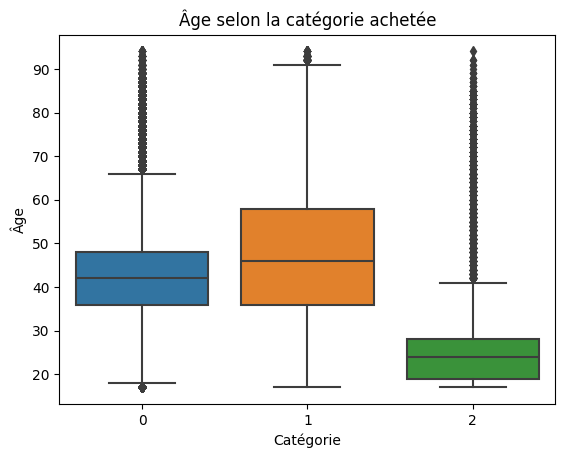

In [104]:
sns.boxplot(data=df_stat, x='categ', y='age')
plt.title("Âge selon la catégorie achetée")
plt.xlabel("Catégorie")
plt.ylabel("Âge")
plt.show()

In [105]:


ages_cat0 = df_stat[df_stat['categ']==0]['age']
ages_cat1 = df_stat[df_stat['categ']==1]['age']
ages_cat2 = df_stat[df_stat['categ']==2]['age']

F, p = f_oneway(ages_cat0, ages_cat1, ages_cat2)
F, p


(39585.51084311452, 0.0)